# Getting started with `gradsolve`

`gradsolve` solves **ensembles** of ordinary differential equations (many trajectories at
once) in JAX and, unlike most fast GPU integrators, can also give you an exact
**reverse-mode gradient** through the solve — so you can back-propagate a loss into the
model's parameters with `jax.grad`, no finite differences required.

This notebook is a short, self-contained tour:

1. Define an ODE as a plain Python object (no registry, no boilerplate).
2. Solve an ensemble of trajectories with one call, auto-routed to a good engine.
3. Solve the *whole batch at once* and see how the wall-clock scales.
4. Differentiate the solve with `jax.grad` and check the gradient against finite
   differences.
5. Peek at the routing table that picks the engine for you.

It imports only `gradsolve` (plus `jax`/`numpy`/`matplotlib`), runs entirely on CPU, and
finishes in well under a minute. It is about the *API*, not about speed: the fused GPU
kernels are not exercised here.

## 1. Setup

Importing `gradsolve` enables `float64` in JAX (accuracy work in this library assumes
double precision) — that's the only side effect of the import.

In [1]:
try:
    import gradsolve  # noqa: F401
except ImportError:  # e.g. on Colab
    %pip install -q git+https://github.com/ECLIPSE-AI4Science/gradsolve.git


In [2]:
%matplotlib inline
import time

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import gradsolve

assert jax.config.jax_enable_x64, "gradsolve should have enabled float64 on import"
print("jax backend:      ", jax.default_backend())
print("float64 enabled:  ", jax.config.jax_enable_x64)

jax backend:       cpu
float64 enabled:   True


## 2. Define your ODE

`gradsolve` needs only a small duck-typed **Problem**: `dim`, `t0`, `t1`, `is_stiff`, and
a JAX right-hand side `f_jax(t, y, params)` for a *single* trajectory — `y` has shape
`(dim,)` and `params` has shape `(P,)` — which gradsolve vmaps over the whole ensemble
for you. No inheritance, no registry — any object with these attributes works.

Below is the Lorenz system, with the parameter $\rho$ varied across the ensemble
(everyone shares $\sigma=10$, $\beta=8/3$).

In [3]:
class Lorenz:
    # Lorenz system as a minimal gradsolve Problem; rho is the per-trajectory parameter.
    name = "notebook_lorenz"
    dim = 3
    t0 = 0.0
    t1 = 1.0
    is_stiff = False

    def f_jax(self, t, y, p):
        rho = p[0]
        return jnp.stack([10.0 * (y[1] - y[0]), rho * y[0] - y[1] - y[0] * y[2], y[0] * y[1] - (8.0 / 3.0) * y[2]])


problem = Lorenz()

n = 32
y0 = np.tile(np.array([1.0, 0.0, 0.0]), (n, 1))            # every trajectory starts here
rho = np.linspace(20.0, 30.0, n)                            # ... but rho varies across the ensemble
params = rho[:, None]                                        # params[n, P] with P=1

print(f"ensemble: n={n} trajectories, dim={problem.dim}, rho in [{rho.min()}, {rho.max()}]")

ensemble: n=32 trajectories, dim=3, rho in [20.0, 30.0]


## 3. Forward solve — one call, auto-routed

`gradsolve.solve` resolves an engine for you (`engine="auto"`) based on the problem's
dimension, stiffness, and (for `grad_closure`, below) whether a gradient is needed —
see [`gradsolve/dispatch.py`](../../gradsolve/dispatch.py). Our `Lorenz` class isn't one
of the library's registered fused-kernel fields, so `solve` falls back to `diffrax`
(the general adaptive engine, when the `diffrax` extra is installed — otherwise
`tsit5_replay`, the general-RHS record-and-replay engine). Both are correct, batched,
and reverse-differentiable — just not the fused GPU speed lane, which needs a
registered field and a CUDA device.

In [4]:
t_start = time.time()
result = gradsolve.solve(problem, y0, params, engine="auto", device="cpu")
elapsed = time.time() - t_start

print(f"engine used:   {result.solver}")
print(f"y_final shape: {result.y_final.shape}")
print(f"wall time:     {elapsed * 1e3:.1f} ms  (n={n} trajectories)")

assert result.y_final.shape == (n, problem.dim)
assert np.all(np.isfinite(result.y_final))

engine used:   diffrax
y_final shape: (32, 3)
wall time:     553.1 ms  (n=32 trajectories)


`result.y_final` is the state of every trajectory at `t1` — that's all a `solve()` call
gives you (it's built to be the thing you differentiate, not a trajectory recorder). To
*look* at a trajectory below, we sweep `t1` and call `solve()` again at each point — a
visualization convenience, not how you'd use the API in production (there you call
`solve()` once, at the `t1` you actually need).

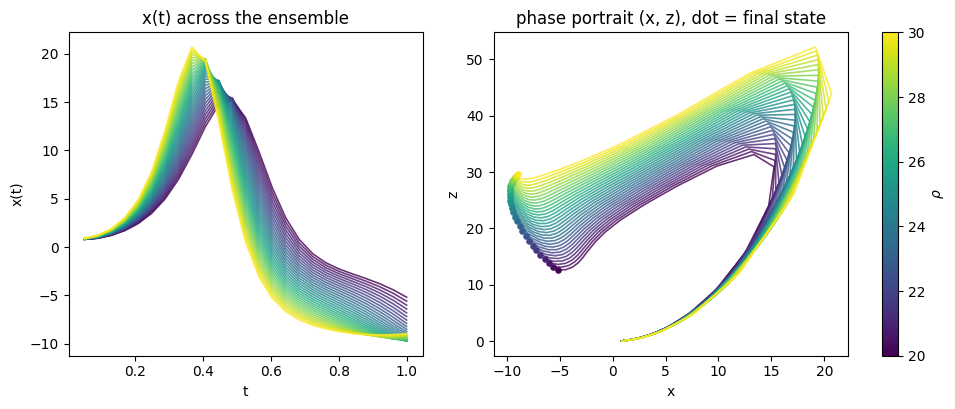

In [5]:
import copy

t_grid = np.linspace(0.05, 1.0, 25)
snapshots = []
for t1 in t_grid:
    snap_problem = copy.copy(problem)
    snap_problem.t1 = float(t1)
    snap = gradsolve.solve(snap_problem, y0, params, engine="auto", device="cpu")
    snapshots.append(snap.y_final)
trajectory = np.stack(snapshots, axis=0)  # (len(t_grid), n, dim)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

cmap = plt.get_cmap("viridis")
colors = cmap((rho - rho.min()) / (rho.max() - rho.min()))

ax = axes[0]
for i in range(n):
    ax.plot(t_grid, trajectory[:, i, 0], color=colors[i], alpha=0.8, lw=1.2)
ax.set_xlabel("t")
ax.set_ylabel("x(t)")
ax.set_title("x(t) across the ensemble")

ax = axes[1]
for i in range(n):
    ax.plot(trajectory[:, i, 0], trajectory[:, i, 2], color=colors[i], alpha=0.8, lw=1.2)
    ax.scatter(trajectory[-1, i, 0], trajectory[-1, i, 2], color=colors[i], s=14, zorder=3)
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_title("phase portrait (x, z), dot = final state")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(rho.min(), rho.max()))
cbar = fig.colorbar(sm, ax=axes, label=r"$\rho$", fraction=0.046, pad=0.04)

plt.show()

## 4. Solve the whole ensemble at once

The point of `gradsolve` is batched solving: one call advances every trajectory
together. Wall-clock should grow much more slowly than linearly with the batch size
for small batches (fixed JIT/dispatch overhead dominates), then track the work once
the batch is large enough to saturate the CPU.

n=   100      86.4 ms
n=  1000     202.5 ms


n=  5000     904.1 ms


n= 10000    1259.3 ms


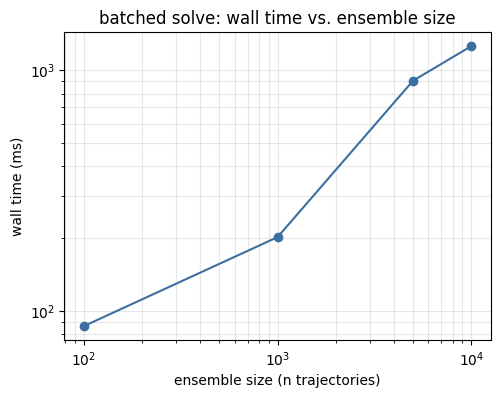

In [6]:
batch_sizes = [100, 1_000, 5_000, 10_000]
times_ms = []
for bn in batch_sizes:
    y0_b = np.tile(np.array([1.0, 0.0, 0.0]), (bn, 1))
    params_b = np.linspace(20.0, 30.0, bn)[:, None]
    t_start = time.time()
    gradsolve.solve(problem, y0_b, params_b, engine="fixed_step_tsit5", device="cpu")
    times_ms.append((time.time() - t_start) * 1e3)
    print(f"n={bn:>6d}  {times_ms[-1]:8.1f} ms")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(batch_sizes, times_ms, "o-", color="#3b6fa0")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("ensemble size (n trajectories)")
ax.set_ylabel("wall time (ms)")
ax.set_title("batched solve: wall time vs. ensemble size")
ax.grid(True, which="both", alpha=0.3)
plt.show()

## 5. Reverse-mode: differentiate through the solve

`gradsolve.grad_closure` returns a `params -> y_final` function that is `jax.grad`-able —
an exact reverse-mode gradient through the ODE solve, which most fast batched GPU
integrators cannot give you at all (they compile the adaptive step loop into an opaque
kernel). Here we differentiate a toy loss (the squared norm of the final state) with
respect to each trajectory's $\rho$.

`engine="auto"` resolves to a record-and-replay adjoint. Because our `Lorenz` class
isn't one of the library's registered fused-kernel fields, on CPU this always falls back
to the portable general-RHS replay (`tsit5_replay`) — it differentiates through `f_jax`
directly, so it works for *any* problem you hand it, at the cost of not using the fused
GPU kernel path (that path needs a registered field and a CUDA device).

In [7]:
final_states = gradsolve.grad_closure(problem, y0, params, engine="auto", device="cpu")

def loss(p):
    return jnp.sum(final_states(p) ** 2)

t_start = time.time()
params_j = jnp.asarray(params)
gradient = jax.grad(loss)(params_j)
elapsed = time.time() - t_start

print(f"grad shape:   {gradient.shape}")
print(f"all finite:   {bool(jnp.all(jnp.isfinite(gradient)))}")
print(f"wall time:    {elapsed * 1e3:.1f} ms  (includes first-call JIT compile)")

assert gradient.shape == params.shape
assert bool(jnp.all(jnp.isfinite(gradient)))

grad shape:   (32, 1)
all finite:   True
wall time:    584.0 ms  (includes first-call JIT compile)


### Sanity-check the gradient against finite differences

We spot-check five trajectories with a central finite difference on $\rho$. Reverse-mode
autodiff should agree to many digits (this is exact discrete-adjoint differentiation,
not an approximation).

In [8]:
check_idx = [0, 8, 16, 24, 31]
eps = 1e-4
fd_grads = []
for i in check_idx:
    p_plus = np.asarray(params, dtype=np.float64).copy()
    p_plus[i, 0] += eps
    p_minus = np.asarray(params, dtype=np.float64).copy()
    p_minus[i, 0] -= eps
    fd = (float(loss(jnp.asarray(p_plus))) - float(loss(jnp.asarray(p_minus)))) / (2 * eps)
    fd_grads.append(fd)

print(f"{'i':>4}  {'rho':>7}  {'jax.grad':>12}  {'finite-diff':>12}  {'rel err':>9}")
for i, fd in zip(check_idx, fd_grads):
    gradient_i = float(gradient[i, 0])
    rel = abs(gradient_i - fd) / (abs(fd) + 1e-12)
    print(f"{i:>4}  {rho[i]:7.2f}  {gradient_i:12.4f}  {fd:12.4f}  {rel:9.2e}")
    assert rel < 1e-2, f"gradient disagrees with finite differences at i={i} (rel={rel:.2e})"

print("\nOK — jax.grad through gradsolve agrees with finite differences")

   i      rho      jax.grad   finite-diff    rel err
   0    20.00       82.0851       82.0851   2.00e-10
   8    22.58      130.3340      130.3340   2.11e-10
  16    25.16       89.5791       89.5791   9.71e-11
  24    27.74       33.4705       33.4705   1.50e-11
  31    30.00       18.0657       18.0657   6.38e-10

OK — jax.grad through gradsolve agrees with finite differences


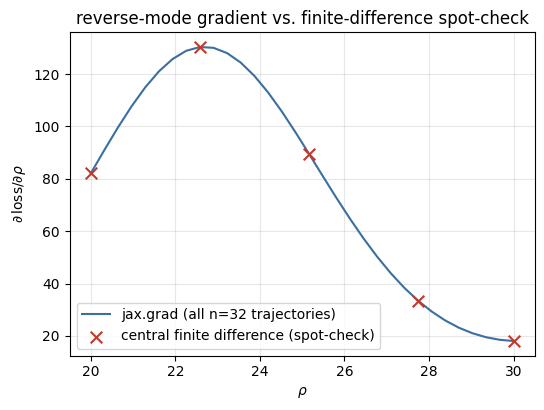

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(rho, np.asarray(gradient)[:, 0], "-", color="#3b6fa0", lw=1.5, label="jax.grad (all n=32 trajectories)")
ax.scatter(rho[check_idx], fd_grads, marker="x", s=70, color="#c0392b", zorder=3,
           label="central finite difference (spot-check)")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$\partial\, \mathrm{loss} / \partial \rho$")
ax.set_title("reverse-mode gradient vs. finite-difference spot-check")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. How routing works

Both calls above used `engine="auto"`. The decision is a pure function of three things:
the state dimension, whether the problem is stiff, and whether a gradient is needed —
see `gradsolve.dispatch.choose_engine` (and the full annotated `DECISION_MAP` in
[`gradsolve/dispatch.py`](../../gradsolve/dispatch.py) for the measured evidence behind
each row). It's total: every combination routes *somewhere*, it never raises.

In [10]:
from gradsolve.dispatch import choose_engine

cases = [
    (3,    False, False),
    (3,    False, True),
    (3,    True,  False),
    (3,    True,  True),
    (32,   False, False),
    (1000, False, False),
    (1000, True,  True),
]

print(f"{'dim':>6}  {'stiff':>6}  {'need_grad':>10}   engine")
print("-" * 46)
for dim, stiff, need_grad in cases:
    engine = choose_engine(dim=dim, stiff=stiff, need_grad=need_grad)
    print(f"{dim:>6}  {str(stiff):>6}  {str(need_grad):>10}   {engine}")

   dim   stiff   need_grad   engine
----------------------------------------------
     3   False       False   cuda_tsit5
     3   False        True   warp_replay
     3    True       False   warp_rosenbrock
     3    True        True   warp_rosenbrock
    32   False       False   warp_ode
  1000   False       False   diffrax
  1000    True        True   rodas5p_replay


The row for our notebook's `(dim=3, stiff=False, need_grad=False)` names `cuda_tsit5` —
the fused hand-CUDA forward lane — which is why `gradsolve.solve` above logged a
*different* engine (`diffrax`): `cuda_tsit5.supports(problem)` requires both an
actual CUDA device (absent in a CPU-only run) *and* a codegen'd field registered
for the problem by name (our `Lorenz` class isn't one). `choose_engine` reports the
*routing policy*; `solve()` and `grad_closure()` additionally check `supports()` and
fall back to a portable engine whenever the chosen one can't run on this hardware or
doesn't recognize this particular problem — which is exactly what happened twice in
this notebook, and is exactly the "Anything else" row of the README's routing
table.